In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
from sksurv.datasets import load_gbsg2
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,32.909589,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,27.715068,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,43.101370,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,47.473973,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,41.490411,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,36.821918,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,40.043836,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,40.964384,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [7]:
# need to choose patient_id from OUS_D1 and OUS_OS_target in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [8]:
# Merge MAASTRO_D1 with response_ous
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [9]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [10]:
# Check if some rows have null values in DFS, DFS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event


In [11]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [12]:
# Change the form of MAASTRO 
# X
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]

# y_MAASTRO into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

# Check the shape of clincial_test
clinical_test.shape

(99, 16)

In [13]:
clinical_train.head(10)

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,32.909589,0
1,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,27.715068,0
2,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,43.101370,1
3,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,47.473973,1
5,57.772603,1,0,0,0,1,1,0.0,0,59.658904,1.0,5.298506,2.846,10.424669,10.126027,1
6,55.791781,0,0,0,0,1,1,0.0,0,56.687671,1.0,8.340148,4.786,31.461777,87.978082,1
7,72.389041,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.301212,7.852,55.919707,53.983562,1
8,53.378082,1,0,1,0,0,1,1.0,0,0.000000,0.0,19.134939,5.898,92.534072,98.005479,0
9,59.076712,0,0,0,1,0,0,0.0,1,41.076712,1.0,17.184191,25.172,317.330329,3.419178,1


In [14]:
clinical_test

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,8.83,1.0
3,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,19.73,1.0
4,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,13.27,1.0
95,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


# Feature Selection

In [62]:
# Define the columns to be excluded from standardization
excluded_columns = ['female', 
                    'cavum_oris',
                    'oropharynx',
                    'hypopharynx',
                    'larynx',
                    'histgrade_high',
                    'hpv_related',
                    'charlson',
                    'uicc8_III-IV'
                   ]

y_event_dfs = y['event_DFS']

final_sum_results = []  # Store sum results across all iterations

for random_state in range(10): 
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    sum_results = []  # Store sum results for each fold
    
    for train_index, test_index in skf.split(X, y_event_dfs):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Standardize the included columns
        scaler = StandardScaler()
        X_train_std = scaler.fit_transform(X_train)
        X_test_std = scaler.transform(X_test)

        # Change it to a dataframe
        X_train_std = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)
        X_test_std = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index)
        
        final_train_df = pd.concat([X_train_std, y_train], axis=1)
        final_test_df = pd.concat([X_test_std, y_test], axis=1)

        # Fit Cox proportional hazards regression model
        coxph = CoxPHFitter(penalizer=0.0001)
        coxph.fit(final_train_df, duration_col='DFS', event_col='event_DFS')

        # Get coefficients and associated feature names
        coefficients = coxph.summary['coef']
        feature_names = coxph.summary.index

        # Create a DataFrame to store coefficients and feature names
        coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

        # Take absolute values of coefficients
        coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

        # Sort coefficients by absolute value to identify important features
        sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)
        
        # Sum absolute coefficients for each feature
        sum_abs_coefficient = sorted_coefficients_df.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
        
        # Append to sum_results for this fold
        sum_results.append(sum_abs_coefficient)

    # Concatenate sum_results for all folds
    fold_sum_results = pd.concat(sum_results)
    
    # Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all folds
    final_sum_fold = fold_sum_results.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
    
    # Append to final_sum_results for all random states
    final_sum_results.append(final_sum_fold)

# Concatenate the DataFrames for all random states
final_result = pd.concat(final_sum_results)

# Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all iterations and folds
final_sum = final_result.groupby('Feature')['Abs_Coefficient'].sum().reset_index()

# Rename the column for clarity
final_sum.columns = ['Feature', 'Final_Sum_Abs_Coefficient']

final_sum_sorted = final_sum.sort_values(by='Final_Sum_Abs_Coefficient', ascending=False)

# Display the final result
print(final_sum_sorted)

<lifelines.CoxPHFitter: fitted with 111 total observations, 56 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 112 total observations, 57 right-censored observations>

...

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 112 total observations, 57 right-censored observations>

           Feature  Final_Sum_Abs_Coefficient
8      hpv_related                  28.334305
2              TLG                  20.662910
0              MTV                  20.041768
12      pack_years                  12.210883
13    uicc8_III-IV                   9.808652
11      oropharynx                   9.190940
9      hypopharynx                   7.702191
10          larynx                   6.742123
1          SUVpeak                   6.449204
5         charlson                   5.995924
3              age                   5.542159
7   histgrade_high                   3.636293
6           female                   3.146326
4       cavum_oris                   3.067572


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 14 artists>

Text(0.5, 0, 'Features')

Text(0, 0.5, 'Sum of Absolute Importance Values')

Text(0.5, 1.0, 'Feature Importance using CoxPH Fitter')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

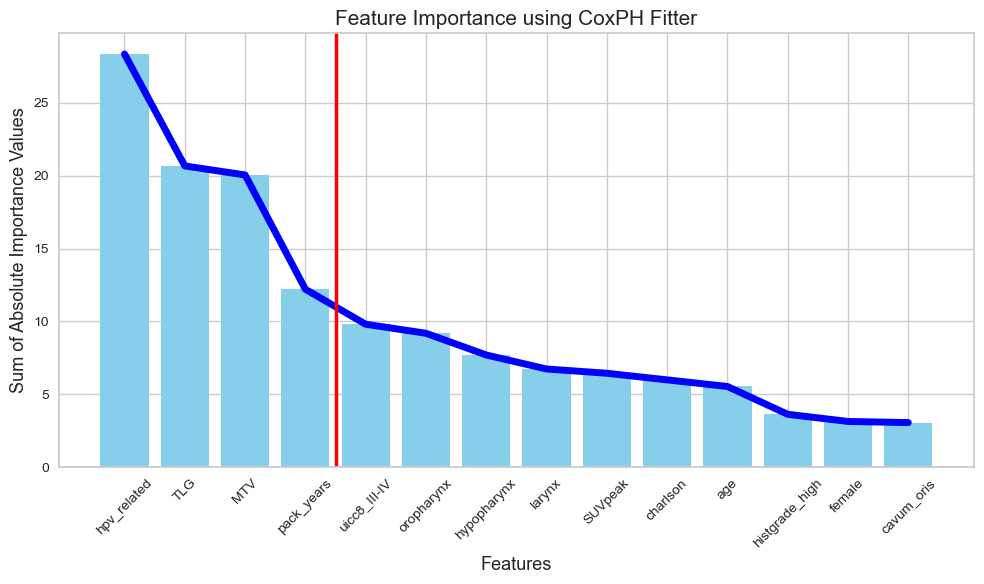

In [108]:
# Plot the bar graph
plt.figure(figsize=(10, 6)) 
plt.bar(final_sum_sorted['Feature'], 
        final_sum_sorted['Final_Sum_Abs_Coefficient'], 
        color='skyblue')
plt.plot(final_sum_sorted['Feature'], 
         final_sum_sorted['Final_Sum_Abs_Coefficient'], 
         color='blue',
        linewidth=5)
plt.xlabel('Features', fontsize=13) 
plt.ylabel('Sum of Absolute Importance Values', fontsize=13) 
plt.title('Feature Importance using CoxPH Fitter', fontsize=15)
plt.xticks(rotation=45) 
plt.axvline(x=3.5, color='red', linestyle='-', linewidth=2.5) 
plt.tight_layout()  
plt.show()

In [109]:
selected_features = final_sum_sorted[0:4]['Feature']
selected_features

8     hpv_related
2             TLG
0             MTV
12     pack_years
Name: Feature, dtype: object

In [110]:
# Selecting features in the DataFrame
X_cfi = X[selected_features]
X_new = X_cfi.copy()

X_MAASTRO_cfi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_cfi.copy()

# Standardization

In [111]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [112]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new  = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [113]:
X_new

,hpv_related,TLG,MTV,pack_years
0,0.0,86.228420,7.934,0.000000
1,0.0,7.040100,1.656,27.404795
2,0.0,83.569669,14.502,41.019178
3,0.0,5.567091,2.440,37.500000
4,0.0,16.150550,3.668,53.000000
...,...,...,...,...
134,1.0,26.280140,3.650,0.000000
135,1.0,101.754834,18.967,0.000000
136,1.0,66.273201,6.370,39.498630
137,1.0,71.832443,12.443,71.527397


In [114]:
X_new_std

,hpv_related,TLG,MTV,pack_years
0,0.0,-0.179158,-0.296907,-1.101176
1,0.0,-0.587333,-0.763433,0.105775
2,0.0,-0.192863,0.191169,0.705374
3,0.0,-0.594926,-0.705173,0.550384
4,0.0,-0.540373,-0.613919,1.233028
...,...,...,...,...
134,1.0,-0.488161,-0.615257,-1.101176
135,1.0,-0.099128,0.522969,-1.101176
136,1.0,-0.282017,-0.413130,0.638406
137,1.0,-0.253362,0.038162,2.049005


In [115]:
MAASTRO_new

,hpv_related,TLG,MTV,pack_years
0,1,263.611623,22.841,0
1,0,36.980700,5.660,20
2,0,74.636342,7.791,6
3,0,46.791979,7.908,45
4,1,107.637514,15.237,59
...,...,...,...,...
94,0,144.490782,6.110,55
95,0,69.214868,7.182,174
96,1,102.594274,16.483,0
97,1,103.229492,9.981,0


In [116]:
MAASTRO_new_std

,hpv_related,TLG,MTV,pack_years
0,1,0.735160,0.810851,-1.101176
1,0,-0.433005,-0.465891,-0.220344
2,0,-0.238909,-0.307534,-0.836927
3,0,-0.382433,-0.298839,0.880696
4,1,-0.068806,0.245788,1.497278
...,...,...,...,...
94,0,0.121154,-0.432451,1.321112
95,0,-0.266854,-0.352789,6.562062
96,1,-0.094801,0.338380,-1.101176
97,1,-0.091527,-0.144792,-1.101176


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [73]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            print(y_train_df)
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])
            print(y_train)

            # y_test into array
            y_test = []      
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)


# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:23:39,725] A new study created in memory with name: no-name-81797f3f-81a2-40f2-a22f-e0cb03d7634c


  0%|          | 0/1 [00:00<?, ?it/s]

           DFS  event_DFS
1    27.715068          0
2    43.101370          1
4    47.473973          1
5    10.126027          1
6    87.978082          1
..         ...        ...
134  41.490411          0
135  36.821918          0
136  40.043836          0
137  40.964384          0
138  30.608219          0

[111 rows x 2 columns]
[(False, 27) ( True, 43) ( True, 47) ( True, 10) ( True, 87) ( True, 53)
 (False, 98) ( True,  3) (False, 58) (False, 20) (False, 76) ( True, 43)
 ( True, 83) ( True, 77) ( True,  2) ( True, 65) ( True, 51) ( True,  4)
 ( True,  3) ( True, 31) (False, 81) (False, 86) ( True,  2) (False, 44)
 (False, 63) (False, 59) ( True,  5) (False,  3) (False, 60) (False, 54)
 ( True,  2) ( True,  3) ( True,  2) (False, 56) (False, 60) ( True,  9)
 ( True, 10) ( True, 28) (False, 68) (False, 57) ( True, 13) ( True, 18)
 ( True,  2) ( True, 26) (False, 59) ( True,  3) (False, 62) ( True,  2)
 ( True, 43) ( True,  2) (False, 38) (False, 31) ( True, 11) (False, 47)
 ( True

[I 2024-04-13 17:23:40,168] A new study created in memory with name: no-name-b1dffe7c-37d9-4ed4-8371-f263507cc2a2


Fold 4 C-index: 0.6653992395437263
           DFS  event_DFS
0    32.909589          0
1    27.715068          0
2    43.101370          1
3    17.589041          1
5    10.126027          1
..         ...        ...
132  24.230137          0
133   5.490411          1
134  41.490411          0
135  36.821918          0
137  40.964384          0

[112 rows x 2 columns]
[(False, 32) (False, 27) ( True, 43) ( True, 17) ( True, 10) ( True, 87)
 ( True, 53) (False, 98) ( True,  3) (False, 58) (False, 20) (False, 76)
 ( True, 43) ( True, 83) ( True, 77) ( True,  2) ( True, 51) ( True,  3)
 ( True, 31) (False, 86) (False, 81) (False, 86) ( True,  2) (False, 40)
 ( True,  3) ( True,  4) (False, 59) (False,  3) (False, 54) ( True,  2)
 ( True,  3) ( True, 18) ( True,  2) ( True,  9) ( True, 10) ( True, 28)
 (False, 57) ( True, 13) ( True,  2) ( True,  2) ( True,  3) ( True, 26)
 (False, 57) (False, 59) ( True,  3) ( True,  2) ( True, 14) (False, 31)
 ( True, 11) ( True,  2) ( True, 13) (False, 

  0%|          | 0/1 [00:00<?, ?it/s]

           DFS  event_DFS
1    27.715068          0
2    43.101370          1
4    47.473973          1
5    10.126027          1
6    87.978082          1
..         ...        ...
134  41.490411          0
135  36.821918          0
136  40.043836          0
137  40.964384          0
138  30.608219          0

[111 rows x 2 columns]
[(False, 27) ( True, 43) ( True, 47) ( True, 10) ( True, 87) ( True, 53)
 (False, 98) ( True,  3) (False, 58) (False, 20) (False, 76) ( True, 43)
 ( True, 83) ( True, 77) ( True,  2) ( True, 65) ( True, 51) ( True,  4)
 ( True,  3) ( True, 31) (False, 81) (False, 86) ( True,  2) (False, 44)
 (False, 63) (False, 59) ( True,  5) (False,  3) (False, 60) (False, 54)
 ( True,  2) ( True,  3) ( True,  2) (False, 56) (False, 60) ( True,  9)
 ( True, 10) ( True, 28) (False, 68) (False, 57) ( True, 13) ( True, 18)
 ( True,  2) ( True, 26) (False, 59) ( True,  3) (False, 62) ( True,  2)
 ( True, 43) ( True,  2) (False, 38) (False, 31) ( True, 11) (False, 47)
 ( True



* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.22385803902952434], datetime_start=datetime.datetime(2024, 4, 13, 17, 23, 40, 206421), datetime_complete=datetime.datetime(2024, 4, 13, 17, 23, 40, 675837), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.22385803902952434


In [74]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [75]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.635
train_ibs:  0.224


#### Test

In [76]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [77]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.581
IBS score: 0.265


In [78]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [79]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [80]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:23:40,959] A new study created in memory with name: no-name-bc58cf6c-ae27-477b-aec6-54cfdf1c6a7a


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-13 17:23:41,236] A new study created in memory with name: no-name-b101ee29-0bc3-4385-a408-6cbdd0f47189


Fold 1 C-index: 0.6454183266932271
Fold 2 C-index: 0.5038759689922481
Fold 3 C-index: 0.5595744680851064
Fold 4 C-index: 0.5171102661596958
Fold 5 C-index: 0.6716738197424893
[I 2024-04-13 17:23:41,221] Trial 0 finished with value: 0.5795305699345532 and parameters: {}. Best is trial 0 with value: 0.5795305699345532.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5795305699345532], datetime_start=datetime.datetime(2024, 4, 13, 17, 23, 41, 52517), datetime_complete=datetime.datetime(2024, 4, 13, 17, 23, 41, 220350), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5795305699345532


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724709627593214
Fold 2 IBS: 0.2320398857267834
Fold 3 IBS: 0.22898186411767818
Fold 4 IBS: 0.24197478573575057
Fold 5 IBS: 0.22939558447779193
[I 2024-04-13 17:23:41,589] Trial 0 finished with value: 0.23592784326678723 and parameters: {}. Best is trial 0 with value: 0.23592784326678723.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784326678723], datetime_start=datetime.datetime(2024, 4, 13, 17, 23, 41, 276608), datetime_complete=datetime.datetime(2024, 4, 13, 17, 23, 41, 589589), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784326678723


In [81]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [82]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.58
train_ibs:  0.236


#### Test

In [83]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [84]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.527


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [85]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [86]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            print("y_train time", max(y_train_df["DFS"]))
            print("y_test time", max(y_test_df["DFS"]))
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y["DFS"], [10, 90])    
                times = np.arange(lower, upper)

                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:23:41,942] A new study created in memory with name: no-name-c55e6178-1184-4b95-85cb-c2f024e461ff


  0%|          | 0/1 [00:00<?, ?it/s]

y_train time 98.00547945
y_test time 86.53150685
Fold 1 C-index: 0.601593625498008
y_train time 98.00547945
y_test time 87.97808219
Fold 2 C-index: 0.6046511627906976
y_train time 98.00547945
y_test time 83.80273973
Fold 3 C-index: 0.7148936170212766
y_train time 87.97808219
y_test time 98.00547945
Fold 4 C-index: 0.6653992395437263
y_train time 98.00547945
y_test time 68.28493151


[I 2024-04-13 17:23:42,552] A new study created in memory with name: no-name-65cf5206-1834-4170-94aa-2d5e36638705


Fold 5 C-index: 0.5793991416309013
[I 2024-04-13 17:23:42,542] Trial 0 finished with value: 0.633187357296922 and parameters: {}. Best is trial 0 with value: 0.633187357296922.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.633187357296922], datetime_start=datetime.datetime(2024, 4, 13, 17, 23, 41, 980457), datetime_complete=datetime.datetime(2024, 4, 13, 17, 23, 42, 541620), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.633187357296922


  0%|          | 0/1 [00:00<?, ?it/s]

y_train time 98.00547945
y_test time 86.53150685
Fold 1 IBS: 0.22843261706348042
y_train time 98.00547945
y_test time 87.97808219
Fold 2 IBS: 0.23062245360881709
y_train time 98.00547945
y_test time 83.80273973
Fold 3 IBS: 0.18539511396163078
y_train time 87.97808219
y_test time 98.00547945
Fold 4 IBS: 0.2576767318639616
y_train time 98.00547945
y_test time 68.28493151
Fold 5 IBS: 0.21020782834033694
[I 2024-04-13 17:23:43,340] Trial 0 finished with value: 0.2224669489676454 and parameters: {}. Best is trial 0 with value: 0.2224669489676454.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2224669489676454], datetime_start=datetime.datetime(2024, 4, 13, 17, 23, 42, 589958), datetime_complete=datetime.datetime(2024, 4, 13, 17, 23, 43, 340520), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2224669489676454


In [87]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [88]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.633
train_ibs:  0.222


#### Test

In [89]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [90]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.581


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.264


In [91]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [92]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])   
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:23:43,700] A new study created in memory with name: no-name-f053a9eb-acb8-4975-af40-7afafb96309e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.601593625498008
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.7148936170212766
Fold 4 C-index: 0.6653992395437263
Fold 5 C-index: 0.5793991416309013
[I 2024-04-13 17:23:44,231] Trial 0 finished with value: 0.6324121634984724 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6324121634984724.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.7148936170212766
Fold 4 C-index: 0.6653992395437263
Fold 5 C-index: 0.5793991416309013
[I 2024-04-13 17:23:44,696] Trial 1 finished with value: 0.6316153507494684 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.6324121634984724.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.7148936170212766
Fold 4 C-index: 0.6653992395437263
Fold 5 C-index: 0.5793991416309013
[I 2024-04-13 17:23:45,259] Trial 2 finished with value: 0.6316153507494684 and parameters: {'l1_ratio': 0.22692876841884668}. 

Fold 1 C-index: 0.601593625498008
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.7148936170212766
Fold 4 C-index: 0.6653992395437263
Fold 5 C-index: 0.5793991416309013
[I 2024-04-13 17:23:55,520] Trial 24 finished with value: 0.6324121634984724 and parameters: {'l1_ratio': 0.7805647035680947}. Best is trial 6 with value: 0.633187357296922.
Fold 1 C-index: 0.601593625498008
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.7148936170212766
Fold 4 C-index: 0.6653992395437263
Fold 5 C-index: 0.5793991416309013
[I 2024-04-13 17:23:56,030] Trial 25 finished with value: 0.6324121634984724 and parameters: {'l1_ratio': 0.9368557715647121}. Best is trial 6 with value: 0.633187357296922.
Fold 1 C-index: 0.6454183266932271
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5553191489361702
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.6652360515021459
[I 2024-04-13 17:23:56,216] Trial 26 finished with value: 0.57927098685408 and parameters: {'l1_ratio': 0.015423757551295547}. Be

Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.7148936170212766
Fold 4 C-index: 0.6653992395437263
Fold 5 C-index: 0.5793991416309013
[I 2024-04-13 17:24:06,369] Trial 48 finished with value: 0.6324121634984724 and parameters: {'l1_ratio': 0.8342998569224302}. Best is trial 6 with value: 0.633187357296922.
Fold 1 C-index: 0.601593625498008
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.7148936170212766
Fold 4 C-index: 0.6653992395437263
Fold 5 C-index: 0.5793991416309013
[I 2024-04-13 17:24:06,803] Trial 49 finished with value: 0.6324121634984724 and parameters: {'l1_ratio': 0.9586049921503356}. Best is trial 6 with value: 0.633187357296922.
Fold 1 C-index: 0.601593625498008
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.7148936170212766
Fold 4 C-index: 0.6653992395437263
Fold 5 C-index: 0.5793991416309013
[I 2024-04-13 17:24:07,249] Trial 50 finished with value: 0.6324121634984724 and parameters: {'l1_ratio': 0.7809764372372684}. Best is trial 6 with value: 0.6331873

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.22724926743691748
Fold 2 IBS: 0.22980620401988117
Fold 3 IBS: 0.18845480673003304
Fold 4 IBS: 0.2627440315006265
Fold 5 IBS: 0.209972783820699
[I 2024-04-13 17:24:34,250] Trial 0 finished with value: 0.22364541870163146 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.22364541870163146.
Fold 1 IBS: 0.22748178635638136
Fold 2 IBS: 0.22988995905259477
Fold 3 IBS: 0.18842099227912332
Fold 4 IBS: 0.26270386863748957
Fold 5 IBS: 0.20956948193861025
[I 2024-04-13 17:24:34,836] Trial 1 finished with value: 0.22361321765283987 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.22361321765283987.
Fold 1 IBS: 0.22750976131432568
Fold 2 IBS: 0.22990172475636125
Fold 3 IBS: 0.18841753331621536
Fold 4 IBS: 0.2626966142149667
Fold 5 IBS: 0.20956626852370627
[I 2024-04-13 17:24:35,583] Trial 2 finished with value: 0.22361838042511506 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 1 with value: 0.2236132176528

Fold 2 IBS: 0.2298349942990868
Fold 3 IBS: 0.18842149540009834
Fold 4 IBS: 0.2627324642599319
Fold 5 IBS: 0.20981887807524507
[I 2024-04-13 17:24:49,634] Trial 25 finished with value: 0.22362886340310997 and parameters: {'l1_ratio': 0.5696287988465819}. Best is trial 14 with value: 0.22360963943086293.
Fold 1 IBS: 0.22737671838538182
Fold 2 IBS: 0.22985484632439784
Fold 3 IBS: 0.18842655879776976
Fold 4 IBS: 0.26271743573482836
Fold 5 IBS: 0.20967467756222144
[I 2024-04-13 17:24:50,176] Trial 26 finished with value: 0.2236100473609198 and parameters: {'l1_ratio': 0.4171478344895766}. Best is trial 14 with value: 0.22360963943086293.
Fold 1 IBS: 0.22734831477634104
Fold 2 IBS: 0.2298445144111228
Fold 3 IBS: 0.18843361775744716
Fold 4 IBS: 0.2627228814328361
Fold 5 IBS: 0.2097326748046328
[I 2024-04-13 17:24:50,875] Trial 27 finished with value: 0.22361640063647598 and parameters: {'l1_ratio': 0.4692701829962466}. Best is trial 14 with value: 0.22360963943086293.
Fold 1 IBS: 0.2272916645

Fold 2 IBS: 0.22989699236294478
Fold 3 IBS: 0.18845193506902497
Fold 4 IBS: 0.262701465713052
Fold 5 IBS: 0.20955419627744226
[I 2024-04-13 17:25:05,005] Trial 50 finished with value: 0.22361205454972638 and parameters: {'l1_ratio': 0.2618182787991173}. Best is trial 46 with value: 0.22360553324525262.
Fold 1 IBS: 0.22750772948323686
Fold 2 IBS: 0.2342191319333795
Fold 3 IBS: 0.18843347014588144
Fold 4 IBS: 0.2626938066241707
Fold 5 IBS: 0.221028178510749
[I 2024-04-13 17:25:05,451] Trial 51 finished with value: 0.22677646333948348 and parameters: {'l1_ratio': 0.19329904439933415}. Best is trial 46 with value: 0.22360553324525262.
Fold 1 IBS: 0.2275036631638143
Fold 2 IBS: 0.22990117792018022
Fold 3 IBS: 0.18842430221430653
Fold 4 IBS: 0.26269553950722546
Fold 5 IBS: 0.20954577361375468
[I 2024-04-13 17:25:06,053] Trial 52 finished with value: 0.22361409128385623 and parameters: {'l1_ratio': 0.2225918073443785}. Best is trial 46 with value: 0.22360553324525262.
Fold 1 IBS: 0.2463825438

Fold 1 IBS: 0.2275271559221733
Fold 2 IBS: 0.23407114769327303
Fold 3 IBS: 0.2244696272044876
Fold 4 IBS: 0.26269271213358375
Fold 5 IBS: 0.2213597907638905
[I 2024-04-13 17:25:20,508] Trial 75 finished with value: 0.2340240867434816 and parameters: {'l1_ratio': 0.1785233853709812}. Best is trial 46 with value: 0.22360553324525262.
Fold 1 IBS: 0.22747463148628724
Fold 2 IBS: 0.22988897842097528
Fold 3 IBS: 0.18843034686117133
Fold 4 IBS: 0.26270243248607567
Fold 5 IBS: 0.20953719346900465
[I 2024-04-13 17:25:21,223] Trial 76 finished with value: 0.22360671654470282 and parameters: {'l1_ratio': 0.2780525411249104}. Best is trial 46 with value: 0.22360553324525262.
Fold 1 IBS: 0.24404996907397797
Fold 2 IBS: 0.23335159590072937
Fold 3 IBS: 0.22570707796685555
Fold 4 IBS: 0.2626819223624307
Fold 5 IBS: 0.22328133263487623
[I 2024-04-13 17:25:21,563] Trial 77 finished with value: 0.23781437958777393 and parameters: {'l1_ratio': 0.1113033243794427}. Best is trial 46 with value: 0.2236055332

In [93]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [94]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.633
train_ibs:  0.224


In [95]:
times

array([ 5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17.,
       18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30.,
       31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41., 42., 43.,
       44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55., 56.,
       57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67., 68., 69.,
       70., 71.])

#### Test

In [96]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [97]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.980766121964777)

test_cindex : 0.581


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.22864446042303133)

test_ibs:  0.236


In [98]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [99]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:25:36,256] A new study created in memory with name: no-name-e607f0a1-52b2-42a9-88fa-00955b540bec


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6772908366533864
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.6085106382978723
Fold 4 C-index: 0.6768060836501901
Fold 5 C-index: 0.5686695278969958
[I 2024-04-13 17:25:42,197] Trial 0 finished with value: 0.6264104560593788 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6264104560593788.
Fold 1 C-index: 0.6055776892430279
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.7127659574468085
Fold 4 C-index: 0.6387832699619772
Fold 5 C-index: 0.5793991416309013
[I 2024-04-13 17:25:46,673] Trial 1 finished with value: 0.6290106380131322 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 

Fold 3 C-index: 0.7276595744680852
Fold 4 C-index: 0.7319391634980988
Fold 5 C-index: 0.5450643776824035
[I 2024-04-13 17:26:55,544] Trial 15 finished with value: 0.6657616789992626 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 16, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 385, 'oob_score': True, 'max_samples': 0.44567908834749126, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1651092422125184, 'warm_start': True}. Best is trial 14 with value: 0.6688662752308251.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:26:59,207] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 17, 'min_samples_leaf': 18, 'max_depth': 1, 'n_estimators': 422, 'oob_score': True, 'max_samples': 0.36871324569404207, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.18198533854133878, 'warm_start': True}. Best is trial 14 with value: 0.6688662752308251.
Fold 1 C-inde

Fold 1 C-index: 0.6892430278884463
Fold 2 C-index: 0.6918604651162791
Fold 3 C-index: 0.7702127659574468
Fold 4 C-index: 0.7110266159695817
Fold 5 C-index: 0.5901287553648069
[I 2024-04-13 17:27:53,431] Trial 30 finished with value: 0.6904943260593122 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 20, 'min_samples_leaf': 14, 'max_depth': 13, 'n_estimators': 228, 'oob_score': True, 'max_samples': 0.817211763101151, 'max_features': None, 'min_weight_fraction_leaf': 0.23690373721361296, 'warm_start': True}. Best is trial 30 with value: 0.6904943260593122.
Fold 1 C-index: 0.6892430278884463
Fold 2 C-index: 0.6821705426356589
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.7072243346007605
Fold 5 C-index: 0.6030042918454935
[I 2024-04-13 17:27:56,274] Trial 31 finished with value: 0.6929241840749228 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 20, 'min_samples_leaf': 14, 'max_depth': 13, 'n_estimators': 228, 'oob_score': True, 'max_samples': 0.8316593432463288

...

Fold 5 IBS: 0.21439284712085574
[I 2024-04-13 17:31:06,498] Trial 31 finished with value: 0.22200865993745184 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 5, 'min_samples_leaf': 15, 'max_depth': 10, 'n_estimators': 91, 'oob_score': False, 'max_samples': 0.6704691817027653, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.17246650649873668}. Best is trial 11 with value: 0.22124373764328661.
Fold 1 IBS: 0.22283521639740814
Fold 2 IBS: 0.22963342542811604
Fold 3 IBS: 0.2148979260179795
Fold 4 IBS: 0.2315135376787964
Fold 5 IBS: 0.21397246819051535
[I 2024-04-13 17:31:08,392] Trial 32 finished with value: 0.2225705147425631 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 2, 'min_samples_leaf': 19, 'max_depth': 18, 'n_estimators': 94, 'oob_score': False, 'max_samples': 0.7228712047671371, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.17832434042487724}. Best is trial 11 with value: 0.22124373764328661.
Fold 1 IBS: 0.22683956657902643
Fold 2 IBS: 0.2303

Fold 1 IBS: 0.21805790464510486
Fold 2 IBS: 0.22876240524412048
Fold 3 IBS: 0.22054694376305545
Fold 4 IBS: 0.23127740108578565
Fold 5 IBS: 0.21440421554189754
[I 2024-04-13 17:31:58,330] Trial 47 finished with value: 0.22260977405599278 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 16, 'min_samples_leaf': 19, 'max_depth': 17, 'n_estimators': 65, 'oob_score': False, 'max_samples': 0.957906057948784, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.2265940792613088}. Best is trial 11 with value: 0.22124373764328661.
Fold 1 IBS: 0.24636007418565287
Fold 2 IBS: 0.23203442041124234
Fold 3 IBS: 0.22991606657910105
Fold 4 IBS: 0.24173120937421805
Fold 5 IBS: 0.23015303816935473
[I 2024-04-13 17:31:59,134] Trial 48 finished with value: 0.23603896174391376 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 2, 'min_samples_leaf': 17, 'max_depth': 8, 'n_estimators': 27, 'oob_score': False, 'max_samples': 0.8683478167437638, 'max_features': None, 'min_weight_fraction_le

Fold 5 IBS: 0.21389123566286075
[I 2024-04-13 17:32:31,201] Trial 62 finished with value: 0.22357719081727329 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 14, 'min_samples_leaf': 14, 'max_depth': 7, 'n_estimators': 37, 'oob_score': False, 'max_samples': 0.719128764425779, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.12361817890384363}. Best is trial 60 with value: 0.22009568382540526.
Fold 1 IBS: 0.22748293649398232
Fold 2 IBS: 0.22845591986020167
Fold 3 IBS: 0.21681159387960658
Fold 4 IBS: 0.22645735195288508
Fold 5 IBS: 0.21314499508595658
[I 2024-04-13 17:32:31,945] Trial 63 finished with value: 0.22247055945452643 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 4, 'min_samples_leaf': 17, 'max_depth': 12, 'n_estimators': 4, 'oob_score': False, 'max_samples': 0.5752788583543285, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.18775173012256005}. Best is trial 60 with value: 0.22009568382540526.
Fold 1 IBS: 0.22402393034293708
Fold 2 IBS: 0.22

Fold 1 IBS: 0.22383324861103662
Fold 2 IBS: 0.2311396623215313
Fold 3 IBS: 0.21546610410885536
Fold 4 IBS: 0.2337545712251111
Fold 5 IBS: 0.21587930468593985
[I 2024-04-13 17:33:06,504] Trial 78 finished with value: 0.22401457819049483 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 6, 'min_samples_leaf': 20, 'max_depth': 20, 'n_estimators': 57, 'oob_score': False, 'max_samples': 0.707133994287833, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.17761453910749428}. Best is trial 73 with value: 0.21945368507095858.
Fold 1 IBS: 0.22211721413505506
Fold 2 IBS: 0.23549301486395718
Fold 3 IBS: 0.22289363615541757
Fold 4 IBS: 0.23712053862306104
Fold 5 IBS: 0.2125146905548454
[I 2024-04-13 17:33:07,687] Trial 79 finished with value: 0.22602781886646728 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 5, 'min_samples_leaf': 20, 'max_depth': 8, 'n_estimators': 43, 'oob_score': False, 'max_samples': 0.8930275254848569, 'max_features': 'auto', 'min_weight_fraction_le

Fold 5 IBS: 0.2160977701219527
[I 2024-04-13 17:33:43,709] Trial 93 finished with value: 0.22263060169241747 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 10, 'min_samples_leaf': 15, 'max_depth': 11, 'n_estimators': 94, 'oob_score': False, 'max_samples': 0.6472301565870403, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.16483139811588382}. Best is trial 73 with value: 0.21945368507095858.
Fold 1 IBS: 0.22313093234173192
Fold 2 IBS: 0.23099742240334148
Fold 3 IBS: 0.21700492084108663
Fold 4 IBS: 0.230383095446458
Fold 5 IBS: 0.21534594242355018
[I 2024-04-13 17:33:46,714] Trial 94 finished with value: 0.22337246269123362 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 4, 'min_samples_leaf': 20, 'max_depth': 13, 'n_estimators': 119, 'oob_score': False, 'max_samples': 0.7006326911121581, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.22892066640811734}. Best is trial 73 with value: 0.21945368507095858.
Fold 1 IBS: 0.22630885058151226
Fold 2 IBS: 0.2

In [100]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [101]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.758
train_ibs:  0.219


#### Test

In [102]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [103]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=7, max_features='auto', max_leaf_nodes=6,
                     max_samples=0.7196148567892628, min_samples_split=10,
                     min_weight_fraction_leaf=0.04159793737719245,
                     n_estimators=145, random_state=123, warm_start=True)

test_cindex:  0.596


RandomSurvivalForest(max_depth=12, max_features='auto', max_leaf_nodes=5,
                     max_samples=0.7540598028556501, min_samples_leaf=18,
                     min_samples_split=14,
                     min_weight_fraction_leaf=0.14516814518409826,
                     n_estimators=2, random_state=123)

test_ibs:  0.237


In [104]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [117]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:38:40,062] A new study created in memory with name: no-name-d6646054-e40e-4472-bbab-4f0daefea836


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6414342629482072
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7893617021276595
Fold 4 C-index: 0.752851711026616
Fold 5 C-index: 0.7017167381974249
[I 2024-04-13 17:38:42,220] Trial 0 finished with value: 0.7104062161933148 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7104062161933148.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:38:47,202] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}

Fold 1 C-index: 0.6633466135458167
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.7382978723404255
Fold 4 C-index: 0.7224334600760456
Fold 5 C-index: 0.5901287553648069
[I 2024-04-13 17:39:47,624] Trial 15 finished with value: 0.6746242860018532 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.7210249788923501.
Fold 1 C-index: 0.6772908366533864
Fold 2 C-index: 0.625968992248062
Fold 3 C-index: 0.6978723404255319
Fold 4 C-index: 0.7186311787072244
Fold 5 C-index: 0.5858369098712446
[I 2024-04-13 17:39:50,833] Trial 16 finished with value: 0.6611200515810899 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.6533864541832669
Fold 2 C-index: 0.6627906976744186
Fold 3 C-index: 0.7914893617021277
Fold 4 C-index: 0.7490494296577946
Fold 5 C-index: 0.6437768240343348
[I 2024-04-13 17:40:39,396] Trial 30 finished with value: 0.7000985534503885 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 3, 'min_samples_leaf': 4, 'max_depth': 12, 'n_estimators': 355, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7262614295600427, 'min_weight_fraction_leaf': 0.020774312173092817}. Best is trial 23 with value: 0.7325468023834966.
Fold 1 C-index: 0.6334661354581673
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7957446808510639
Fold 4 C-index: 0.7490494296577946
Fold 5 C-index: 0.703862660944206
[I 2024-04-13 17:40:43,124] Trial 31 finished with value: 0.7097579147155797 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 8, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 409, 'oob_score': False, 'warm_start': True, 'max_featur

...

Fold 1 IBS: 0.22467401004506193
Fold 2 IBS: 0.22316354640587308
Fold 3 IBS: 0.207725764604122
Fold 4 IBS: 0.22171640481030253
Fold 5 IBS: 0.21270695173709128
[I 2024-04-13 17:51:18,692] Trial 30 finished with value: 0.2179973355204902 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 8, 'min_samples_leaf': 9, 'max_depth': 11, 'n_estimators': 355, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7262614295600427, 'min_weight_fraction_leaf': 0.04228849156393042}. Best is trial 12 with value: 0.21637003774435545.
Fold 1 IBS: 0.22392680189738398
Fold 2 IBS: 0.2229294709851197
Fold 3 IBS: 0.20260429606653346
Fold 4 IBS: 0.22001386032339879
Fold 5 IBS: 0.21297409541105125
[I 2024-04-13 17:51:31,084] Trial 31 finished with value: 0.21648970493669745 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 5, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 401, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.62

Fold 1 IBS: 0.22406764569214133
Fold 2 IBS: 0.22351182590702137
Fold 3 IBS: 0.20656326047120274
Fold 4 IBS: 0.22073762966884833
Fold 5 IBS: 0.2127090369172016
[I 2024-04-13 17:54:55,666] Trial 45 finished with value: 0.21751787973128306 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 3, 'n_estimators': 407, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.9297423317874312, 'min_weight_fraction_leaf': 0.11471987108564939}. Best is trial 42 with value: 0.21582341249785286.
Fold 1 IBS: 0.22559996407046734
Fold 2 IBS: 0.22385341911899165
Fold 3 IBS: 0.21049115626571457
Fold 4 IBS: 0.22232739392042378
Fold 5 IBS: 0.21309217356426935
[I 2024-04-13 17:55:12,685] Trial 46 finished with value: 0.21907282138797335 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 9, 'min_samples_leaf': 12, 'max_depth': 5, 'n_estimators': 482, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0

Fold 1 IBS: 0.2237020470864605
Fold 2 IBS: 0.2220818503727144
Fold 3 IBS: 0.20614946549055474
Fold 4 IBS: 0.22064719343475922
Fold 5 IBS: 0.21219673020247834
[I 2024-04-13 17:58:41,835] Trial 60 finished with value: 0.21695545731739346 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 2, 'n_estimators': 102, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.8544257673865696, 'min_weight_fraction_leaf': 0.10590227147730576}. Best is trial 42 with value: 0.21582341249785286.
Fold 1 IBS: 0.22347963365635373
Fold 2 IBS: 0.2253270759581801
Fold 3 IBS: 0.20092167404261776
Fold 4 IBS: 0.22044374497924232
Fold 5 IBS: 0.21285439927211597
[I 2024-04-13 17:59:04,640] Trial 61 finished with value: 0.21660530558170196 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 20, 'min_samples_leaf': 2, 'max_depth': 4, 'n_estimators': 446, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0

Fold 1 IBS: 0.2231382339253733
Fold 2 IBS: 0.22399715507678827
Fold 3 IBS: 0.20342595124531174
Fold 4 IBS: 0.219537790437295
Fold 5 IBS: 0.21222842391173802
[I 2024-04-13 18:03:16,914] Trial 75 finished with value: 0.21646551091930127 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 17, 'min_samples_leaf': 3, 'max_depth': 5, 'n_estimators': 458, 'oob_score': False, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.9251033837722725, 'min_weight_fraction_leaf': 0.07480260088405158}. Best is trial 42 with value: 0.21582341249785286.
Fold 1 IBS: 0.22362477591249766
Fold 2 IBS: 0.22350876903010716
Fold 3 IBS: 0.20472574744649544
Fold 4 IBS: 0.22044053600981323
Fold 5 IBS: 0.2127499348099368
[I 2024-04-13 18:03:35,219] Trial 76 finished with value: 0.21700995264177006 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 19, 'min_samples_leaf': 1, 'max_depth': 7, 'n_estimators': 499, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.

Fold 1 IBS: 0.22230167959487637
Fold 2 IBS: 0.2238734905791108
Fold 3 IBS: 0.20071620887386388
Fold 4 IBS: 0.22405744426455187
Fold 5 IBS: 0.21122155117575658
[I 2024-04-13 18:07:07,158] Trial 90 finished with value: 0.2164340748976319 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 16, 'min_samples_leaf': 1, 'max_depth': 2, 'n_estimators': 425, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.8288038860590615, 'min_weight_fraction_leaf': 0.013165780985775847}. Best is trial 42 with value: 0.21582341249785286.
Fold 1 IBS: 0.22205503362506374
Fold 2 IBS: 0.22584537230400223
Fold 3 IBS: 0.20041308089415738
Fold 4 IBS: 0.22079466971703907
Fold 5 IBS: 0.2119721366001817
[I 2024-04-13 18:07:20,908] Trial 91 finished with value: 0.21621605862808885 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 14, 'min_samples_leaf': 2, 'max_depth': 3, 'n_estimators': 450, 'oob_score': False, 'warm_start': False, 'max_features': 'sqrt', 'max_samples':

In [118]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [119]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.75
train_ibs:  0.216


#### Test

In [120]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [121]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=14, max_leaf_nodes=20,
                   max_samples=0.8834616695959974, min_samples_leaf=1,
                   min_samples_split=19,
                   min_weight_fraction_leaf=0.006894459391585722,
                   n_estimators=459, random_state=123, warm_start=True)

C-index score: 0.614


ExtraSurvivalTrees(max_depth=6, max_features='log2', max_leaf_nodes=5,
                   max_samples=0.9277628436989306, min_samples_split=8,
                   min_weight_fraction_leaf=0.028954072511129886,
                   n_estimators=448, random_state=123, warm_start=True)

IBS: 0.22


In [122]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [123]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 18:09:35,719] A new study created in memory with name: no-name-88cb410b-a458-41ae-ae88-4ff8fc2e3b34


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:10:49,455] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:11:23,665] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:29:04,184] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 12 with value: 0.6177781016441521.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:31:21,272] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'squar

Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:52:15,064] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 22 with value: 0.6263130381523598.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:54:29,241] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction

...

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:18:25,570] Trial 44 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5628832155203615, 'learning_rate': 0.05692286295358468, 'dropout_rate': 0.683156188511181, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 9.07255185322531, 'min_weight_fraction_leaf': 0.21518215373385774, 'max_features': None, 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.8420815814864784, 'min_samples_split': 3, 'max_leaf_nodes': 11, 'min_samples_leaf': 17, 'max_depth': 10}. Best is trial 22 with value: 0.23565938846824253.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 21:18:36,751] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.9436582561003044, 'learning_rate': 0.07482848784358435,

Fold 3 IBS: 0.22719230439732646
Fold 4 IBS: 0.24055525488516177
Fold 5 IBS: 0.2274575163367958
[I 2024-04-13 21:31:03,207] Trial 55 finished with value: 0.2339539322397622 and parameters: {'subsample': 0.5887322566034815, 'learning_rate': 0.03248154248395621, 'dropout_rate': 0.20419816136861105, 'n_estimators': 357, 'criterion': 'friedman_mse', 'ccp_alpha': 0.036799960796019306, 'min_weight_fraction_leaf': 0.30861253825639257, 'max_features': None, 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4978860670989092, 'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 9, 'max_depth': 13}. Best is trial 51 with value: 0.23314478439186273.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:32:17,342] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.48190513355031883, 'learning_rate': 0.0308849767405

Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 21:41:04,930] Trial 66 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6883221930691388, 'learning_rate': 0.043486677645014335, 'dropout_rate': 0.17314117987651884, 'n_estimators': 300, 'criterion': 'friedman_mse', 'ccp_alpha': 1.392319704490283, 'min_weight_fraction_leaf': 0.3364958462902864, 'max_features': None, 'min_impurity_decrease': 0.0002596209104718211, 'validation_fraction': 0.3924562181388663, 'min_samples_split': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 7, 'max_depth': 15}. Best is trial 65 with value: 0.2325927485711851.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:42:07,157] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6123270626634933, 'learning_rate': 0.03766085593505888, 'dropout_rate': 0.12110767967

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 22:03:59,119] Trial 78 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6246097794699133, 'learning_rate': 0.04647316253399379, 'dropout_rate': 0.2683524876236738, 'n_estimators': 390, 'criterion': 'friedman_mse', 'ccp_alpha': 0.9868967429041097, 'min_weight_fraction_leaf': 0.3963858435471036, 'max_features': None, 'min_impurity_decrease': 0.00034235487966359176, 'validation_fraction': 0.6768490350713532, 'min_samples_split': 5, 'max_leaf_nodes': 2, 'min_samples_leaf': 12, 'max_depth': 11}. Best is trial 65 with value: 0.2325927485711851.
Fold 1 IBS: 0.24640717053292358
Fold 2 IBS: 0.23131875943843325
Fold 3 IBS: 0.22824901974829898
Fold 4 IBS: 0.24142247109050252
Fold 5 IBS: 0.228841254524273
[I 2024-04-13 22:07:47,145] Trial 79 finished with value: 0.2352477350668863 and parameters: {'subsa

Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 22:23:36,387] Trial 89 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7062934300236606, 'learning_rate': 0.04049073641133963, 'dropout_rate': 0.10286028062555917, 'n_estimators': 321, 'criterion': 'friedman_mse', 'ccp_alpha': 0.5179367484462377, 'min_weight_fraction_leaf': 0.3812326539458533, 'max_features': None, 'min_impurity_decrease': 0.01806689386438656, 'validation_fraction': 0.43928293695272114, 'min_samples_split': 3, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 11}. Best is trial 65 with value: 0.2325927485711851.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 22:24:31,611] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.3053150575440778, 'learning_rate': 0.05817657886326664,

In [124]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [125]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.637
train_ibs:  0.233


#### Test

In [126]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [127]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.02268722073535837,
                                 dropout_rate=0.9121998303968706,
                                 learning_rate=0.0869328686638194, max_depth=19,
                                 max_features=1, max_leaf_nodes=15,
                                 min_impurity_decrease=3.6052234045258807e-05,
                                 min_samples_leaf=16, min_samples_split=10,
                                 min_weight_fraction_leaf=0.12242559141327672,
                                 n_estimators=127, random_state=123,
                                 subsample=0.44833281273469094,
                                 validation_fraction=0.310720291270915)

C-index score: 0.601


GradientBoostingSurvivalAnalysis(ccp_alpha=0.0027463880859729187,
                                 dropout_rate=0.16871798720386325,
                                 learning_rate=0.04324945527987548,
                                 max_depth=15, max_leaf_nodes=5,
                                 min_impurity_decrease=0.0005159101285841248,
                                 min_samples_leaf=7, min_samples_split=3,
                                 min_weight_fraction_leaf=0.3355883872029622,
                                 n_estimators=300, random_state=123,
                                 subsample=0.6891090397922855,
                                 validation_fraction=0.4525371458863552)

IBS: 0.225


In [128]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis


#### Train

In [129]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:33:58,443] A new study created in memory with name: no-name-2e8df86c-1980-4138-9a57-5aa8d8d22966


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.649402390438247
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5553191489361702
Fold 4 C-index: 0.4752851711026616
Fold 5 C-index: 0.6437768240343348
[I 2024-04-13 23:33:59,753] Trial 0 finished with value: 0.5643691100030579 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5643691100030579.
Fold 1 C-index: 0.649402390438247
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5553191489361702
Fold 4 C-index: 0.4752851711026616
Fold 5 C-index: 0.6437768240343348
[I 2024-04-13 23:34:21,009] Trial 1 finished with value: 0.5643691100030579 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5643691100030579.
Fold 1 C-index: 0.6573705179282868
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5574468085106383
Fold

Fold 1 C-index: 0.6772908366533864
Fold 2 C-index: 0.5193798449612403
Fold 3 C-index: 0.6127659574468085
Fold 4 C-index: 0.6197718631178707
Fold 5 C-index: 0.6609442060085837
[I 2024-04-13 23:35:56,756] Trial 19 finished with value: 0.6180305416375779 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7254192287154788, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 19 with value: 0.6180305416375779.
Fold 1 C-index: 0.6613545816733067
Fold 2 C-index: 0.5116279069767442
Fold 3 C-index: 0.5702127659574469
Fold 4 C-index: 0.5171102661596958
Fold 5 C-index: 0.6566523605150214
[I 2024-04-13 23:35:57,377] Trial 20 finished with value: 0.583391576256443 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.7351566261790888, 'n_estimators': 54, 'learning_rate': 0.03789546527738753}. Best is trial 19 with value: 0.6180305416375779.
Fold 1 C-index: 0.6693227091633466
Fold 2 C-index: 0.5155038759689923
Fold 3 C-index: 0.6085106382978723
Fo

Fold 1 C-index: 0.6733067729083665
Fold 2 C-index: 0.5116279069767442
Fold 3 C-index: 0.6
Fold 4 C-index: 0.5513307984790875
Fold 5 C-index: 0.6652360515021459
[I 2024-04-13 23:36:17,964] Trial 38 finished with value: 0.6003003059732688 and parameters: {'subsample': 0.10045702238474481, 'dropout_rate': 0.4692748186370167, 'n_estimators': 106, 'learning_rate': 0.02446715861883563}. Best is trial 33 with value: 0.6210871042573203.
Fold 1 C-index: 0.6613545816733067
Fold 2 C-index: 0.5116279069767442
Fold 3 C-index: 0.5659574468085107
Fold 4 C-index: 0.5475285171102662
Fold 5 C-index: 0.648068669527897
[I 2024-04-13 23:36:18,639] Trial 39 finished with value: 0.586907424419345 and parameters: {'subsample': 0.24699060465984554, 'dropout_rate': 0.6565066423402253, 'n_estimators': 51, 'learning_rate': 0.06892741183938003}. Best is trial 33 with value: 0.6210871042573203.
Fold 1 C-index: 0.6454183266932271
Fold 2 C-index: 0.49806201550387597
Fold 3 C-index: 0.5531914893617021
Fold 4 C-index: 

...

Fold 3 IBS: 0.24980651809706036
Fold 4 IBS: 0.32212551331365513
Fold 5 IBS: 0.2118750443523794
[I 2024-04-13 23:38:57,056] Trial 19 finished with value: 0.2654536086777627 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.9949834936920623, 'n_estimators': 134, 'learning_rate': 0.036212385990032875}. Best is trial 11 with value: 0.23568340855424386.
Fold 1 IBS: 0.23811757243152712
Fold 2 IBS: 0.2398149800769366
Fold 3 IBS: 0.21920608859079785
Fold 4 IBS: 0.27338696756381375
Fold 5 IBS: 0.2217394787490562
[I 2024-04-13 23:38:57,823] Trial 20 finished with value: 0.23845301748242634 and parameters: {'subsample': 0.9139336698304192, 'dropout_rate': 0.6485024664008028, 'n_estimators': 61, 'learning_rate': 0.017331004877487094}. Best is trial 11 with value: 0.23568340855424386.
Fold 1 IBS: 0.24705948941812342
Fold 2 IBS: 0.23211248685734326
Fold 3 IBS: 0.22874241725022804
Fold 4 IBS: 0.24228315811623524
Fold 5 IBS: 0.22924789552503783
[I 2024-04-13 23:38:58,320] Trial 21 fi

Fold 4 IBS: 0.24517824421830312
Fold 5 IBS: 0.22798620580966658
[I 2024-04-13 23:39:24,524] Trial 38 finished with value: 0.23568181306700858 and parameters: {'subsample': 0.7400823249602382, 'dropout_rate': 0.2937559455046105, 'n_estimators': 31, 'learning_rate': 0.0052991863727216565}. Best is trial 38 with value: 0.23568181306700858.
Fold 1 IBS: 0.2342054926214641
Fold 2 IBS: 0.2992532463758293
Fold 3 IBS: 0.24650367458040967
Fold 4 IBS: 0.3185016449576861
Fold 5 IBS: 0.21041396038719767
[I 2024-04-13 23:39:28,488] Trial 39 finished with value: 0.26177560378451736 and parameters: {'subsample': 0.7451120589355307, 'dropout_rate': 0.11764036968298192, 'n_estimators': 216, 'learning_rate': 0.02276024519147273}. Best is trial 38 with value: 0.23568181306700858.
Fold 1 IBS: 0.23229715496947795
Fold 2 IBS: 0.29123199883935286
Fold 3 IBS: 0.2420506164233966
Fold 4 IBS: 0.31444093681962343
Fold 5 IBS: 0.2057983833019615
[I 2024-04-13 23:39:29,494] Trial 40 finished with value: 0.25716381807

Fold 5 IBS: 0.21763275187288678
[I 2024-04-13 23:39:47,799] Trial 57 finished with value: 0.23425773185770687 and parameters: {'subsample': 0.13165605060453595, 'dropout_rate': 0.3057121124924377, 'n_estimators': 84, 'learning_rate': 0.014955776210569753}. Best is trial 57 with value: 0.23425773185770687.
Fold 1 IBS: 0.22698517465413362
Fold 2 IBS: 0.272736669377447
Fold 3 IBS: 0.22780839936875372
Fold 4 IBS: 0.2864869562181433
Fold 5 IBS: 0.19815415084074883
[I 2024-04-13 23:39:53,371] Trial 58 finished with value: 0.24243427009184532 and parameters: {'subsample': 0.17217492616009322, 'dropout_rate': 0.3089475281627602, 'n_estimators': 297, 'learning_rate': 0.01430072400134189}. Best is trial 57 with value: 0.23425773185770687.
Fold 1 IBS: 0.23858525627988994
Fold 2 IBS: 0.23804567810614938
Fold 3 IBS: 0.21977490695502275
Fold 4 IBS: 0.26703888874646786
Fold 5 IBS: 0.2200108839532338
[I 2024-04-13 23:39:54,469] Trial 59 finished with value: 0.23669112280815274 and parameters: {'subsam

Fold 1 IBS: 0.24209186316556572
Fold 2 IBS: 0.2334121049676723
Fold 3 IBS: 0.22327601124967508
Fold 4 IBS: 0.2530979201790424
Fold 5 IBS: 0.22551564701939814
[I 2024-04-13 23:40:12,581] Trial 77 finished with value: 0.23547870931627074 and parameters: {'subsample': 0.1909060533270752, 'dropout_rate': 0.5123597792687312, 'n_estimators': 20, 'learning_rate': 0.025512570062193523}. Best is trial 76 with value: 0.23370532823537551.
Fold 1 IBS: 0.23298146919274437
Fold 2 IBS: 0.24419751490199273
Fold 3 IBS: 0.21678048151197654
Fold 4 IBS: 0.27792606270416675
Fold 5 IBS: 0.21282794519250833
[I 2024-04-13 23:40:13,355] Trial 78 finished with value: 0.23694269470067772 and parameters: {'subsample': 0.23957179565357356, 'dropout_rate': 0.5174512478263339, 'n_estimators': 66, 'learning_rate': 0.02789014880830545}. Best is trial 76 with value: 0.23370532823537551.
Fold 1 IBS: 0.24640513166212769
Fold 2 IBS: 0.2322531877520054
Fold 3 IBS: 0.22843324909165605
Fold 4 IBS: 0.24216616558924406
Fold 5 

Fold 1 IBS: 0.24577645281515695
Fold 2 IBS: 0.23226976015858009
Fold 3 IBS: 0.2271634204392849
Fold 4 IBS: 0.24230433193845838
Fold 5 IBS: 0.22632999761846684
[I 2024-04-13 23:40:52,085] Trial 96 finished with value: 0.23476879259398942 and parameters: {'subsample': 0.1178482056138237, 'dropout_rate': 0.504599054186659, 'n_estimators': 7, 'learning_rate': 0.02973183625552351}. Best is trial 76 with value: 0.23370532823537551.
Fold 1 IBS: 0.22698657270561298
Fold 2 IBS: 0.2543559472430592
Fold 3 IBS: 0.22039823770948438
Fold 4 IBS: 0.28173831577059466
Fold 5 IBS: 0.20194524593252805
[I 2024-04-13 23:40:55,082] Trial 97 finished with value: 0.23708486387225589 and parameters: {'subsample': 0.1428225879209601, 'dropout_rate': 0.4899196550430742, 'n_estimators': 196, 'learning_rate': 0.016713299209988923}. Best is trial 76 with value: 0.23370532823537551.
Fold 1 IBS: 0.2405161373474778
Fold 2 IBS: 0.23498227694267118
Fold 3 IBS: 0.22112728800053635
Fold 4 IBS: 0.2505586538677983
Fold 5 IBS

In [130]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [131]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.621
train_ibs:  0.233


#### Test

In [132]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [133]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.5201443025102012,
                                              learning_rate=0.05879386689092163,
                                              n_estimators=94, random_state=123,
                                              subsample=0.10119033004596172)

C-index score: 0.542


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.411720091014581,
                                              learning_rate=0.034736443350412746,
                                              n_estimators=23, random_state=123,
                                              subsample=0.1834840296856905)

IBS: 0.235


In [134]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [135]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.758,1.0
ExtraSurvivalTrees,0.750,2.0
GradientBoosting,0.637,3.0
CoxPH,0.635,4.0
CoxLasso,0.633,5.5
CoxElastic,0.633,5.5
ComponentwiseGradientBoosting,0.621,7.0
CoxRidge,0.580,8.0


In [136]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.216,1.0
Randomsurvivalforest,0.219,2.0
CoxLasso,0.222,3.0
CoxPH,0.224,4.5
CoxElastic,0.224,4.5
GradientBoosting,0.233,6.5
ComponentwiseGradientBoosting,0.233,6.5
CoxRidge,0.236,8.0


In [137]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.614,1.0
GradientBoosting,0.601,2.0
Randomsurvivalforest,0.596,3.0
CoxPH,0.581,5.0
CoxLasso,0.581,5.0
CoxElastic,0.581,5.0
ComponentwiseGradientBoosting,0.542,7.0
CoxRidge,0.527,8.0


In [138]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.220,1.0
GradientBoosting,0.225,2.0
CoxRidge,0.229,3.0
ComponentwiseGradientBoosting,0.235,4.0
CoxElastic,0.236,5.0
Randomsurvivalforest,0.237,6.0
CoxLasso,0.264,7.0
CoxPH,0.265,8.0


In [139]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/dfs/standard/cfi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_dfs_standard_cfi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [140]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-13
